# Exploratory Data Analysis

**Objective:** Understand the data structure, identify predictive features and document decisions before building the feature engineering pipeline.

**Dataset:** `application_train.csv` : 307 511 loan applications, 122 columns

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_PATH   = r'C:\Users\Fama\home-credit-risk\data\raw\application_train.csv'
OUTPUT_PATH = r'C:\Users\Fama\home-credit-risk\data\references'

In [4]:
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nDtype breakdown:\n{df.dtypes.value_counts()}')
df.head(3)

Shape: 307,511 rows × 122 columns

Dtype breakdown:
float64    65
int64      41
object     16
Name: count, dtype: int64


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0000,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0000,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.5559,0.

In [5]:
print('TARGET distribution:')
print(df['TARGET'].value_counts())
print(f'\nDefault rate: {df["TARGET"].mean():.2%}')

TARGET distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate: 8.07%


**Observations:**
- 8.,07% default rate → highly imbalanced dataset
- Modeling will require class weighting (`scale_pos_weight`) or resampling

## Missing Values <a id='3'></a>

In [6]:
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0].reset_index()
missing.columns = ['column', 'missing_rate']

print(f'{len(missing)} columns with missing values')
print(f'\nTop 20:')
display(missing.head(20))

67 columns with missing values

Top 20:


,column,missing_rate
0,COMMONAREA_AVG,0.6987
1,COMMONAREA_MODE,0.6987
2,COMMONAREA_MEDI,0.6987
3,NONLIVINGAPARTMENTS_MEDI,0.6943
4,NONLIVINGAPARTMENTS_MODE,0.6943
5,NONLIVINGAPARTMENTS_AVG,0.6943
6,FONDKAPREMONT_MODE,0.6839
7,LIVINGAPARTMENTS_AVG,0.6835
8,LIVINGAPARTMENTS_MEDI,0.6835
9,LIVINGAPARTMENTS_MODE,0.6835


In [7]:

already_identified = [
    'SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'AMT_CREDIT',
    'AMT_ANNUITY', 'AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE',
    'CODE_GENDER', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
    'FLAG_MOBIL', 'FLAG_EMAIL', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY'
]

# Usable candidated < 20% missing and not yet in the pipeline
candidates = [
    c for c in missing.query('missing_rate < 0.2')['column']
    if c not in already_identified
]

print(f'{len(candidates)} new candidate columns with < 20% missing:')
print('\n'.join(candidates))

15 new candidate columns with < 20% missing:
EXT_SOURCE_3
AMT_REQ_CREDIT_BUREAU_HOUR
AMT_REQ_CREDIT_BUREAU_WEEK
AMT_REQ_CREDIT_BUREAU_MON
AMT_REQ_CREDIT_BUREAU_YEAR
AMT_REQ_CREDIT_BUREAU_DAY
AMT_REQ_CREDIT_BUREAU_QRT
NAME_TYPE_SUITE
DEF_60_CNT_SOCIAL_CIRCLE
OBS_60_CNT_SOCIAL_CIRCLE
DEF_30_CNT_SOCIAL_CIRCLE
OBS_30_CNT_SOCIAL_CIRCLE
EXT_SOURCE_2
CNT_FAM_MEMBERS
DAYS_LAST_PHONE_CHANGE



- Building-related columns (`COMMONAREA_*`, `FLOORSMIN_*`, `YEARS_BUILD_*`) have 65–70% missing → excluded
- `OWN_CAR_AGE` has 66% missing, expected because since most clients don't own a car
- 15 new candidates with < 20% missing → evaluated below

## Target Analysis <a id='4'></a>

In [8]:
# Gender gap
print('Default rate by gender:')
print(df.groupby('CODE_GENDER')['TARGET'].agg(['mean', 'count', 'sum']).round(4))

Default rate by gender:
              mean   count    sum
CODE_GENDER                      
F           0.0700  202448  14170
M           0.1014  105059  10655
XNA         0.0000       4      0


In [9]:
df['age_group'] = pd.cut(
    -df['DAYS_BIRTH'] / 365,
    bins=[0, 25, 35, 45, 55, 100],
    labels=['<25', '25-35', '35-45', '45-55', '>55']
)

print('Default rate by age group:')
print(df.groupby('age_group', observed=True)['TARGET'].agg(['mean', 'count']).round(3))

Default rate by age group:
            mean  count
age_group              
<25       0.1230  12159
25-35     0.1070  72302
35-45     0.0840  84274
45-55     0.0710  70077
>55       0.0520  68699


- Women: 7.0% default, Men: 10.1% → 3.1 point real gap
- Age follows a clear monotonic pattern: <25 → 12.5%, >55 → 5.3%, younger clients carry significantly higher risk

## Numerical Features <a id='5'></a>

In [10]:
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c != 'TARGET']

corr_target = (
    df[num_cols].corrwith(df['TARGET'])
    .abs()
    .sort_values(ascending=False)
)

print('Top 20 numerical features by |correlation| with TARGET:')
print(corr_target.head(20).round(4))

Top 20 numerical features by |correlation| with TARGET:
EXT_SOURCE_3                  0.1789
EXT_SOURCE_2                  0.1605
EXT_SOURCE_1                  0.1553
DAYS_BIRTH                    0.0782
REGION_RATING_CLIENT_W_CITY   0.0609
REGION_RATING_CLIENT          0.0589
DAYS_LAST_PHONE_CHANGE        0.0552
DAYS_ID_PUBLISH               0.0515
REG_CITY_NOT_WORK_CITY        0.0510
FLAG_EMP_PHONE                0.0460
DAYS_EMPLOYED                 0.0449
REG_CITY_NOT_LIVE_CITY        0.0444
FLAG_DOCUMENT_3               0.0443
FLOORSMAX_AVG                 0.0440
FLOORSMAX_MEDI                0.0438
FLOORSMAX_MODE                0.0432
DAYS_REGISTRATION             0.0420
AMT_GOODS_PRICE               0.0396
OWN_CAR_AGE                   0.0376
REGION_POPULATION_RELATIVE    0.0372
dtype: float64


In [11]:
# EXT_SOURCE = normalized scores from external credit bureaus
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    corr = df[col].corr(df['TARGET'])
    nan_rate = df[col].isnull().mean()
    print(f'{col}: corr={corr:.4f}  missing={nan_rate:.2%}')

EXT_SOURCE_1: corr=-0.1553  missing=56.38%
EXT_SOURCE_2: corr=-0.1605  missing=0.21%
EXT_SOURCE_3: corr=-0.1789  missing=19.83%


In [12]:
# Check redundancy between two region rating columns
r = df['REGION_RATING_CLIENT'].corr(df['REGION_RATING_CLIENT_W_CITY'])
print(f'REGION_RATING_CLIENT vs W_CITY: corr={r:.4f}')
print('→ Keep W_CITY only (more granular, higher corr with TARGET)')

REGION_RATING_CLIENT vs W_CITY: corr=0.9508
→ Keep W_CITY only (more granular, higher corr with TARGET)


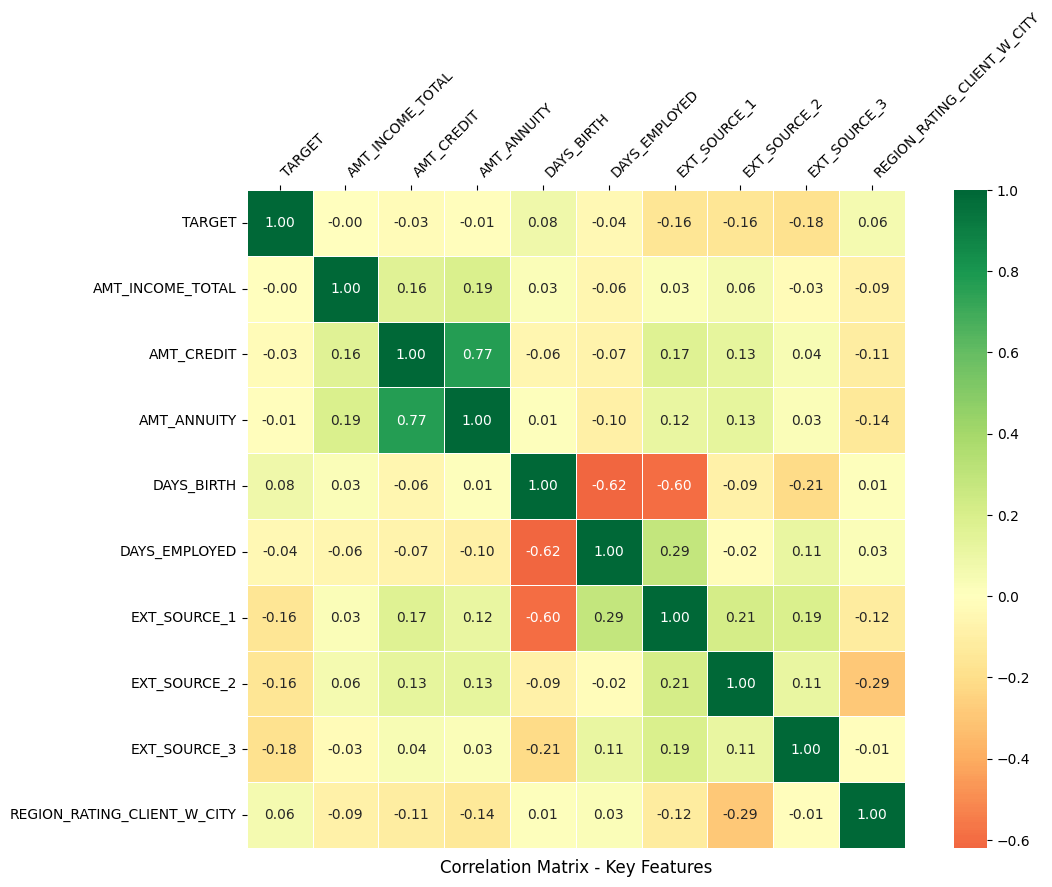

In [15]:
key_features = [
    'TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'DAYS_BIRTH', 'DAYS_EMPLOYED',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'REGION_RATING_CLIENT_W_CITY'
]

corr_matrix = df[key_features].corr().round(2)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.xticks(rotation=45, ha='left')
plt.title('Correlation Matrix - Key Features', pad=20, y=-0.08)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}\\correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

- `EXT_SOURCE_2` and `EXT_SOURCE_3` are the strongest predictors (|corr| = 0.16, 0.18) -> must include
- `EXT_SOURCE_1` strong but 56% missing -> include with a binary availability flag
- `AMT_CREDIT` / `AMT_ANNUITY` corr = 0.77 -> keep both, their ratio carries additional signal
- `DAYS_BIRTH` / `DAYS_EMPLOYED` corr = -0.62 -> expected (older = more tenure), both kept
- LightGBM handles residual multicollinearity via tree structure

## Categorical Features <a id='6'></a>

In [16]:
cat_cols = [c for c in df.select_dtypes('object').columns if c != 'TARGET']

print(f'{"Column":<35} {"Spread":>8} {"N categories":>14}')
print('-' * 60)
for col in cat_cols:
    dr = df.groupby(col)['TARGET'].mean()
    spread = dr.max() - dr.min()
    print(f'{col:<35} {spread:>8.4f} {df[col].nunique():>14}')

Column                                Spread   N categories
------------------------------------------------------------
NAME_CONTRACT_TYPE                    0.0287              2
CODE_GENDER                           0.1014              3
FLAG_OWN_CAR                          0.0126              2
FLAG_OWN_REALTY                       0.0036              2
NAME_TYPE_SUITE                       0.0245              7
NAME_INCOME_TYPE                      0.4000              8
NAME_EDUCATION_TYPE                   0.0910              5
NAME_FAMILY_STATUS                    0.0994              6
NAME_HOUSING_TYPE                     0.0574              6
OCCUPATION_TYPE                       0.1232             18
WEEKDAY_APPR_PROCESS_START            0.0059              7
ORGANIZATION_TYPE                     0.1263             58
FONDKAPREMONT_MODE                    0.0172              4
HOUSETYPE_MODE                        0.0320              3
WALLSMATERIAL_MODE                    0

In [17]:
print('Default rate by NAME_INCOME_TYPE:')
print(
    df.groupby('NAME_INCOME_TYPE')['TARGET']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
    .round(3)
)

Default rate by NAME_INCOME_TYPE:
                       mean   count
NAME_INCOME_TYPE                   
Maternity leave      0.4000       5
Unemployed           0.3640      22
Working              0.0960  158774
Commercial associate 0.0750   71617
State servant        0.0580   21703
Pensioner            0.0540   55362
Businessman          0.0000      10
Student              0.0000      18


In [18]:
print('Default rate by OCCUPATION_TYPE:')
print(
    df.groupby('OCCUPATION_TYPE')['TARGET']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
    .round(3)
)

Default rate by OCCUPATION_TYPE:
                        mean  count
OCCUPATION_TYPE                    
Low-skill Laborers    0.1720   2093
Drivers               0.1130  18603
Waiters/barmen staff  0.1130   1348
Security staff        0.1070   6721
Laborers              0.1060  55186
Cooking staff         0.1040   5946
Sales staff           0.0960  32102
Cleaning staff        0.0960   4653
Realty agents         0.0790    751
Secretaries           0.0700   1305
Medicine staff        0.0670   8537
Private service staff 0.0660   2652
IT staff              0.0650    526
HR staff              0.0640    563
Core staff            0.0630  27570
Managers              0.0620  21371
High skill tech staff 0.0620  11380
Accountants           0.0480   9813


In [19]:
print('Default rate by NAME_EDUCATION_TYPE:')
print(
    df.groupby('NAME_EDUCATION_TYPE')['TARGET']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
    .round(3)
)

Default rate by NAME_EDUCATION_TYPE:
                                mean   count
NAME_EDUCATION_TYPE                         
Lower secondary               0.1090    3816
Secondary / secondary special 0.0890  218391
Incomplete higher             0.0850   10277
Higher education              0.0540   74863
Academic degree               0.0180     164


- `NAME_INCOME_TYPE` spread = 0.40, strongest categorical signal
  - Pensioners (5.4%) vs Working (9.6%), stable income matters
  - Maternity/Unemployed excluded from comparison (< 25 samples each)
- `OCCUPATION_TYPE` spread = 0.123,  Low-skill Laborers at 17.2%, Accountants at 4.8%
- `NAME_EDUCATION_TYPE` clean monotonic relationship: Academic degree (2%) → Lower secondary (11%)
- `WEEKDAY_APPR_PROCESS_START` spread = 0.006 — no predictive value, excluded

## Visualizations <a id='7'></a>

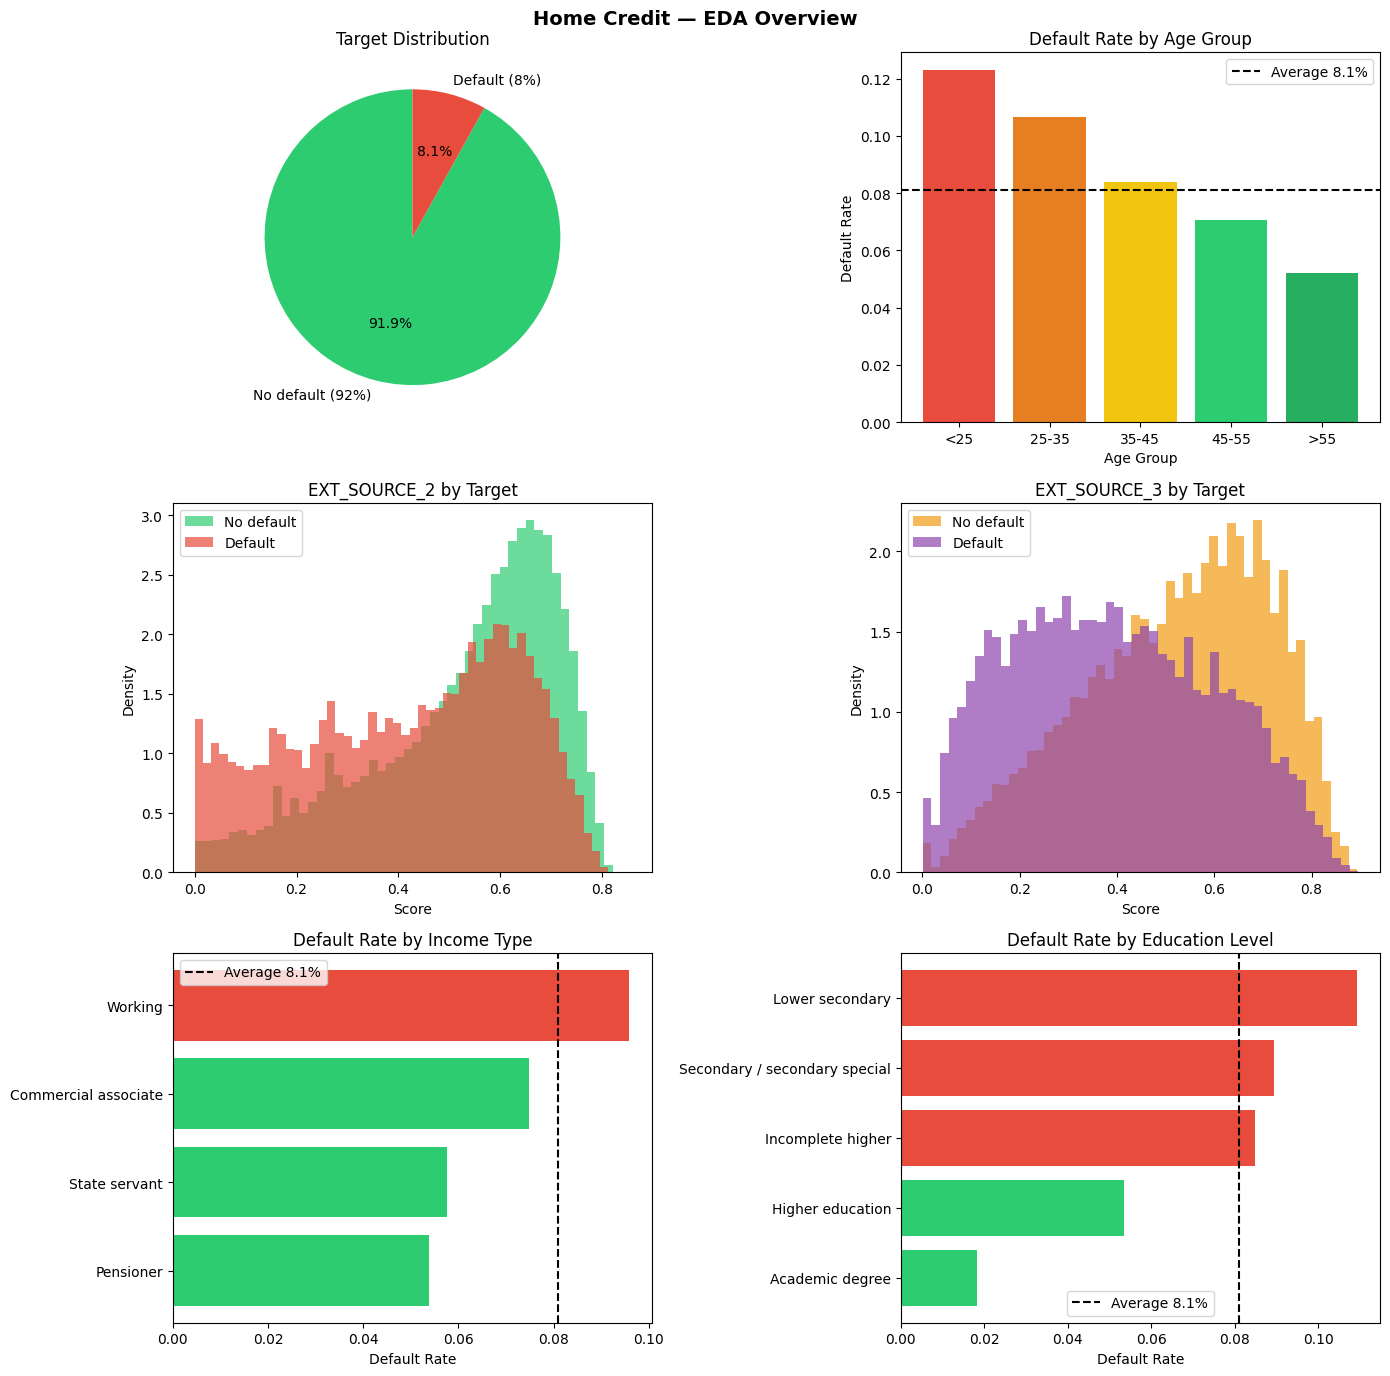

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle('Home Credit — EDA Overview', fontsize=14, fontweight='bold')

# Target distribution
axes[0, 0].pie(
    df['TARGET'].value_counts(),
    labels=['No default (92%)', 'Default (8%)'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%', startangle=90
)
axes[0, 0].set_title('Target Distribution')

# Default rate by age group
age_dr = df.groupby('age_group', observed=True)['TARGET'].mean()
axes[0, 1].bar(age_dr.index, age_dr.values,
               color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60'])
axes[0, 1].axhline(0.081, color='black', linestyle='--', label='Average 8.1%')
axes[0, 1].set_title('Default Rate by Age Group')
axes[0, 1].set_xlabel('Age Group')
axes[0, 1].set_ylabel('Default Rate')
axes[0, 1].legend()

# EXT_SOURCE_2 density normalized to compensate for class imbalance
df_ext = df[['EXT_SOURCE_2', 'EXT_SOURCE_3', 'TARGET']].dropna()
for target, color, label in [(0, '#2ecc71', 'No default'), (1, '#e74c3c', 'Default')]:
    axes[1, 0].hist(df_ext[df_ext['TARGET'] == target]['EXT_SOURCE_2'],
                    bins=50, alpha=0.7, color=color, label=label, density=True)
axes[1, 0].set_title('EXT_SOURCE_2 by Target')
axes[1, 0].set_xlabel('Score')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()

# EXT_SOURCE_3
for target, color, label in [(0, '#f39c12', 'No default'), (1, '#8e44ad', 'Default')]:
    axes[1, 1].hist(df_ext[df_ext['TARGET'] == target]['EXT_SOURCE_3'],
                    bins=50, alpha=0.7, color=color, label=label, density=True)
axes[1, 1].set_title('EXT_SOURCE_3 by Target')
axes[1, 1].set_xlabel('Score')
axes[1, 1].set_ylabel('Density')
axes[1, 1].legend()

# Default rate by income type red/green relative to average
income_dr = df.groupby('NAME_INCOME_TYPE')['TARGET'].mean().sort_values()
income_dr = income_dr[income_dr.index.isin(
    ['Working', 'Commercial associate', 'State servant', 'Pensioner']
)]
axes[2, 0].barh(income_dr.index, income_dr.values,
                color=['#e74c3c' if v > 0.081 else '#2ecc71' for v in income_dr.values])
axes[2, 0].axvline(0.081, color='black', linestyle='--', label='Average 8.1%')
axes[2, 0].set_title('Default Rate by Income Type')
axes[2, 0].set_xlabel('Default Rate')
axes[2, 0].legend()

edu_dr = df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values()
axes[2, 1].barh(edu_dr.index, edu_dr.values,
                color=['#e74c3c' if v > 0.081 else '#2ecc71' for v in edu_dr.values])
axes[2, 1].axvline(0.081, color='black', linestyle='--', label='Average 8.1%')
axes[2, 1].set_title('Default Rate by Education Level')
axes[2, 1].set_xlabel('Default Rate')
axes[2, 1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}\\eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

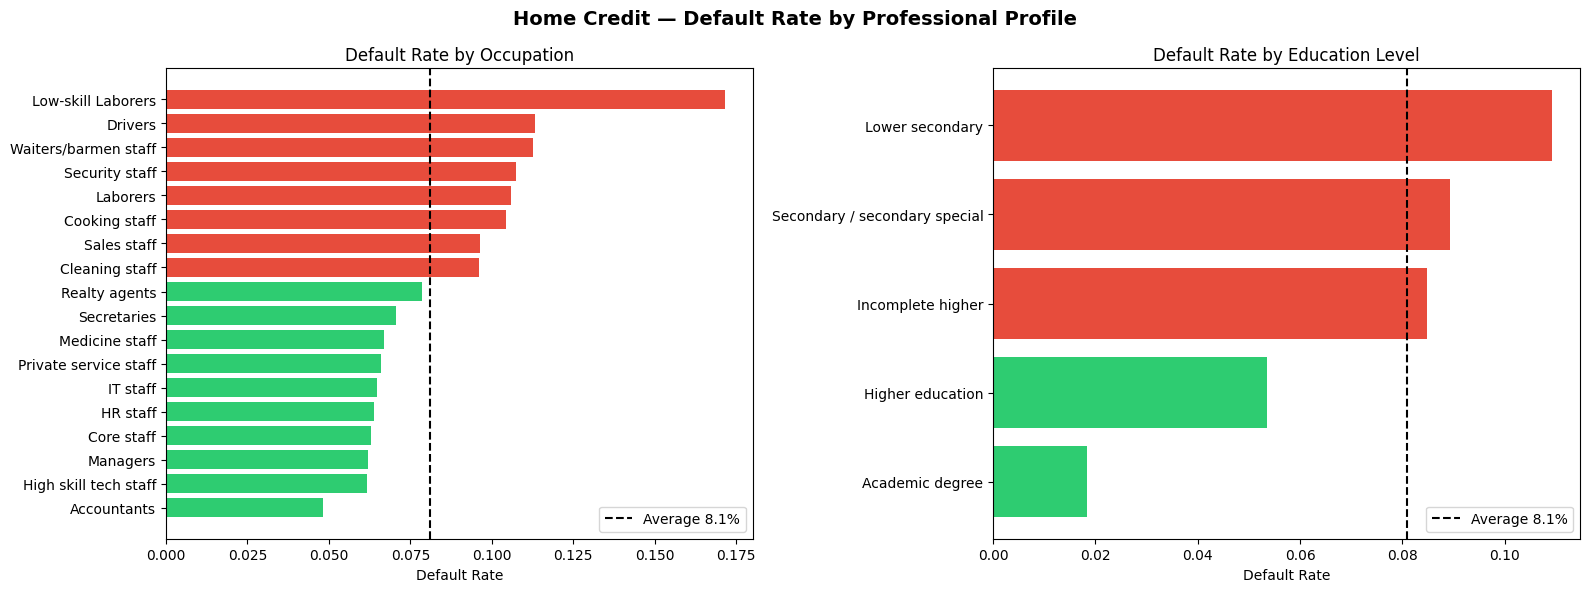

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Home Credit — Default Rate by Professional Profile', fontsize=14, fontweight='bold')

occ_dr = df.groupby('OCCUPATION_TYPE')['TARGET'].mean().sort_values()
axes[0].barh(occ_dr.index, occ_dr.values,
             color=['#e74c3c' if v > 0.081 else '#2ecc71' for v in occ_dr.values])
axes[0].axvline(0.081, color='black', linestyle='--', label='Average 8.1%')
axes[0].set_title('Default Rate by Occupation')
axes[0].set_xlabel('Default Rate')
axes[0].legend()

edu_dr = df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values()
axes[1].barh(edu_dr.index, edu_dr.values,
             color=['#e74c3c' if v > 0.081 else '#2ecc71' for v in edu_dr.values])
axes[1].axvline(0.081, color='black', linestyle='--', label='Average 8.1%')
axes[1].set_title('Default Rate by Education Level')
axes[1].set_xlabel('Default Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}\\eda_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Selection <a id='8'></a>

### New numerical features to add

| Feature | \|corr\| with TARGET | Missing | Rationale |
|---------|----------------------|---------|----------|
| `EXT_SOURCE_2` | 0.161 | 0.2% | External credit score  |
| `EXT_SOURCE_3` | 0.179 | 19.8% | External credit score  |
| `EXT_SOURCE_1` | 0.155 | 56.4% | Strong signal, add with availability flag |
| `REGION_RATING_CLIENT_W_CITY` | 0.061 | 0% | Regional risk score (city-adjusted) |
| `DAYS_ID_PUBLISH` | 0.051 | 0% | Document renewal, stability proxy |
| `REG_CITY_NOT_WORK_CITY` | 0.051 | 0% | Lives and works in different cities |
| `DAYS_REGISTRATION` | 0.042 | 0% | Residential stability |
| `FLAG_DOCUMENT_3` | 0.044 | 0% | Compliance with document requirements |

### New categorical features to add

| Feature | Spread | Rationale |
|---------|--------|-----------|
| `NAME_INCOME_TYPE` | 0.40 | Strongest categorical predictor |
| `OCCUPATION_TYPE` | 0.123 | Clear socio-economic risk gradient |
| `NAME_EDUCATION_TYPE` | 0.091 | Monotonic relationship with default rate |
| `NAME_FAMILY_STATUS` | 0.099 | Family situation affects repayment capacity |

### Excluded features

| Feature | Reason |
|---------|--------|
| `COMMONAREA_*`, `FLOORSMIN_*`, `YEARS_BUILD_*` | 65–70% missing, weak signal |
| `REGION_RATING_CLIENT` | corr = 0.95 with W_CITY version redundant |
| `WEEKDAY_APPR_PROCESS_START` | Spread = 0.006, no predictive value |